# Oil Price Exploratory Data Analysis (EDA)
This notebook explores the daily oil price dataset (`oil.csv`) and its relationship with the training data range.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Find the project root containing pyproject.toml
root = Path.cwd()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

from configs.config import RAW_DIR

## 1. Basic Structure & Date Range Comparison
We check the shape, start/end dates, and compare them with the training set dates (`train.csv`).

In [2]:
oil = pd.read_csv(RAW_DIR / 'oil.csv')
train = pd.read_csv(RAW_DIR / 'train.csv')

print(f"Oil dataset shape: {oil.shape}")
print(f"Oil date range: {oil['date'].min()} to {oil['date'].max()}")
print(f"Train date range: {train['date'].min()} to {train['date'].max()}")

oil['date'] = pd.to_datetime(oil['date'])
train['date'] = pd.to_datetime(train['date'])

# Range comparison
print(f"Oil starts {oil['date'].min().date()} vs Train {train['date'].min().date()}")
print(f"Oil ends {oil['date'].max().date()} vs Train {train['date'].max().date()}")

Oil dataset shape: (1218, 2)
Oil date range: 2013-01-01 to 2017-08-31
Train date range: 2013-01-01 to 2017-08-15
Oil starts 2013-01-01 vs Train 2013-01-01
Oil ends 2017-08-31 vs Train 2017-08-15


## 2. Missing Dates and Reindexing
We check for missing dates inside oil's own range (due to weekends and holidays) and the percentage of NaNs after reindexing to match the training set.

In [3]:
# Raw missing values inside oil's own range
oil_own_range = pd.date_range(start=oil['date'].min(), end=oil['date'].max(), freq='D')
missing_days_raw = len(oil_own_range) - oil['date'].nunique()
print(f"Total days in oil's own range: {len(oil_own_range)}")
print(f"Unique dates in oil.csv: {oil['date'].nunique()}")
print(f"Missing calendar days (weekends/holidays): {missing_days_raw} ({missing_days_raw/len(oil_own_range)*100:.2f}%)")

# Missing values inside raw oil['dcoilwtico']
print(f"Missing values in raw dcoilwtico column: {oil['dcoilwtico'].isna().sum()}")

# Reindexing to train range
train_range = pd.date_range(start=train['date'].min(), end=train['date'].max(), freq='D')
oil_reindexed = oil.set_index('date').reindex(train_range)
oil_reindexed.index.name = 'date'

total_nans_reindexed = oil_reindexed['dcoilwtico'].isna().sum()
print(f"\nAfter reindexing to train range:")
print(f"Total days in train range: {len(train_range)}")
print(f"Total NaN values in reindexed series: {total_nans_reindexed}")
print(f"Percentage NaN in reindexed series: {total_nans_reindexed/len(train_range)*100:.2f}%")

Total days in oil's own range: 1704
Unique dates in oil.csv: 1218
Missing calendar days (weekends/holidays): 486 (28.52%)
Missing values in raw dcoilwtico column: 43

After reindexing to train range:
Total days in train range: 1688
Total NaN values in reindexed series: 525
Percentage NaN in reindexed series: 31.10%


## 3. Missing Value Imputation (ffill vs. Linear Interpolation)
We compare two primary fill methods: Forward fill (ffill) and Linear interpolation. We plot their overlay and zoom in on a holiday period (Christmas/New Year 2013-2014) to see the difference.

Max absolute difference between ffill and linear: 3.8800
Mean absolute difference: 0.1400

Overlay during Christmas/New Year 2013-2014:
              Raw  ffill     linear  difference
2013-12-20  99.11  99.11  99.110000    0.000000
2013-12-21    NaN  99.11  98.946667    0.163333
2013-12-22    NaN  99.11  98.783333    0.326667
2013-12-23  98.62  98.62  98.620000    0.000000
2013-12-24  98.87  98.87  98.870000    0.000000
2013-12-25    NaN  98.87  99.025000    0.155000
2013-12-26  99.18  99.18  99.180000    0.000000
2013-12-27  99.94  99.94  99.940000    0.000000
2013-12-28    NaN  99.94  99.593333    0.346667
2013-12-29    NaN  99.94  99.246667    0.693333
2013-12-30  98.90  98.90  98.900000    0.000000
2013-12-31  98.17  98.17  98.170000    0.000000
2014-01-01    NaN  98.17  96.655000    1.515000
2014-01-02  95.14  95.14  95.140000    0.000000
2014-01-03  93.66  93.66  93.660000    0.000000
2014-01-04    NaN  93.66  93.480000    0.180000
2014-01-05    NaN  93.66  93.300000    0.360000


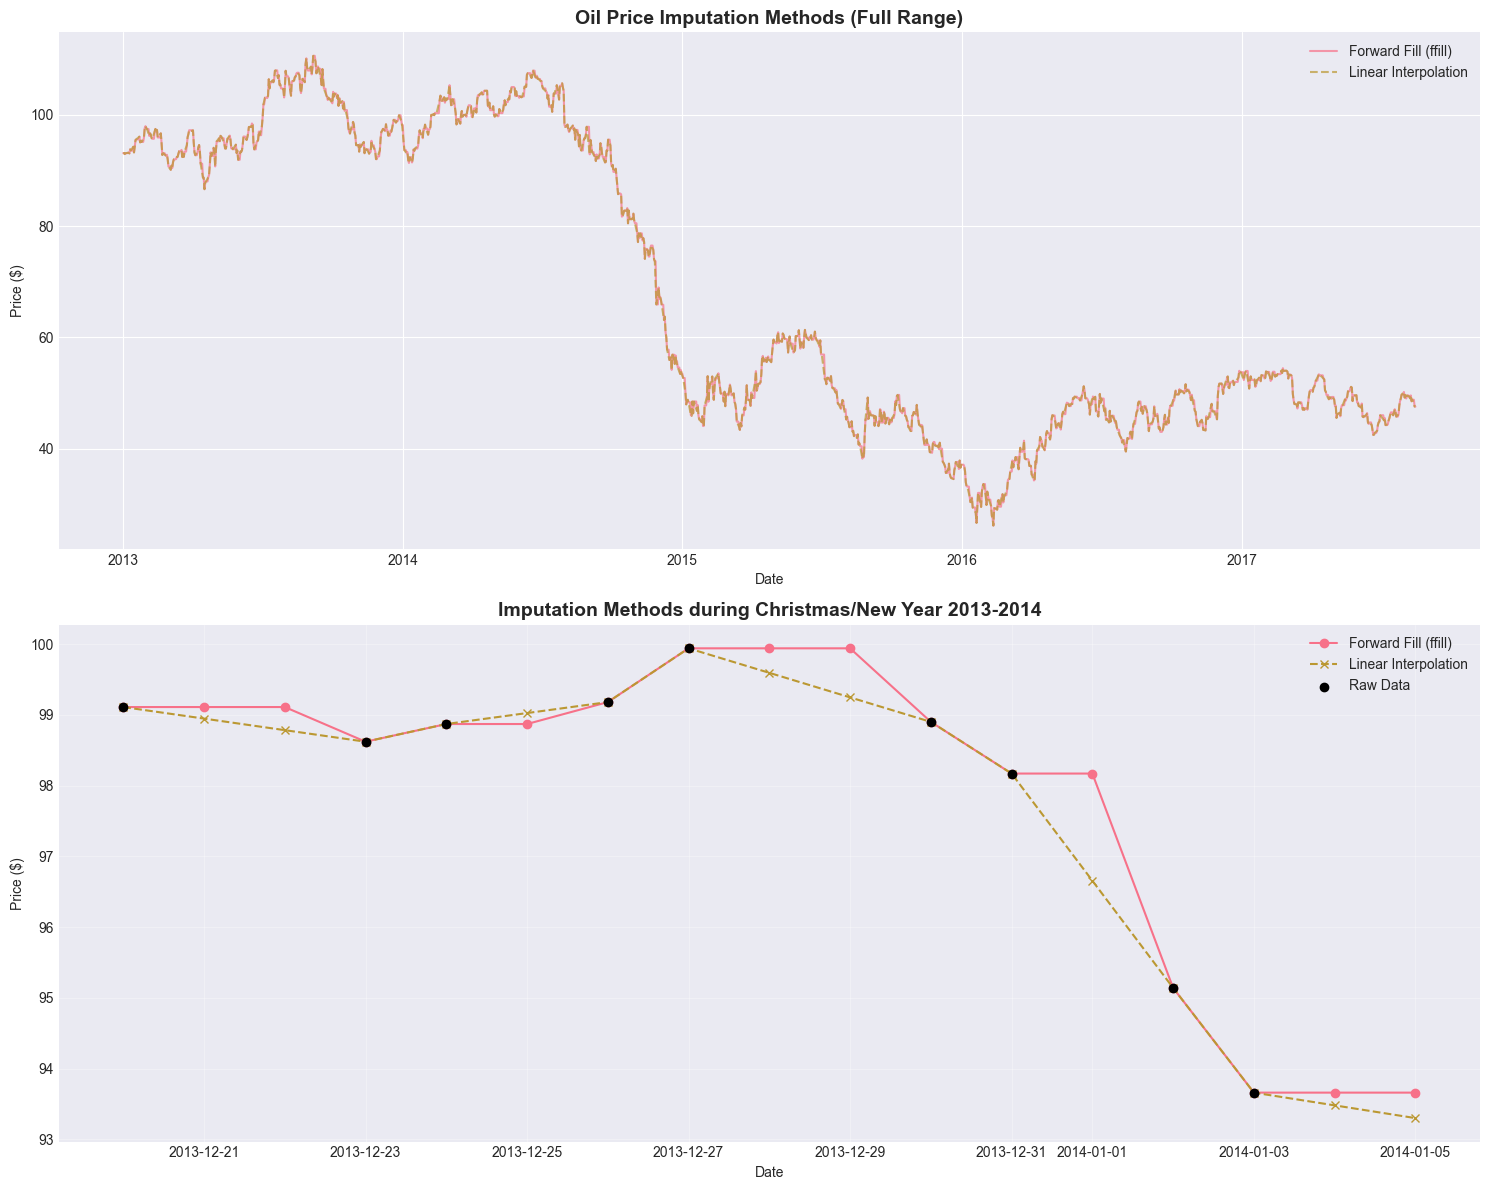

In [4]:
# Create filled series
oil_ffill = oil_reindexed['dcoilwtico'].ffill().bfill()
oil_linear = oil_reindexed['dcoilwtico'].interpolate(method='linear').bfill()

# Compute difference statistics
diff = (oil_ffill - oil_linear).abs()
print(f"Max absolute difference between ffill and linear: {diff.max():.4f}")
print(f"Mean absolute difference: {diff.mean():.4f}")

# Zoom in on holiday period (2013-12-20 to 2014-01-05)
holiday_range = pd.date_range(start='2013-12-20', end='2014-01-05')
holiday_df = pd.DataFrame({
    'Raw': oil_reindexed.loc[holiday_range, 'dcoilwtico'],
    'ffill': oil_ffill.loc[holiday_range],
    'linear': oil_linear.loc[holiday_range],
    'difference': diff.loc[holiday_range]
})
print("\nOverlay during Christmas/New Year 2013-2014:")
print(holiday_df.to_string())

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Full series comparison
axes[0].plot(oil_ffill.index, oil_ffill, label='Forward Fill (ffill)', alpha=0.7)
axes[0].plot(oil_linear.index, oil_linear, label='Linear Interpolation', alpha=0.7, linestyle='--')
axes[0].set_title('Oil Price Imputation Methods (Full Range)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].legend()

# Zoomed-in holiday period comparison
axes[1].plot(holiday_df.index, holiday_df['ffill'], marker='o', label='Forward Fill (ffill)')
axes[1].plot(holiday_df.index, holiday_df['linear'], marker='x', linestyle='--', label='Linear Interpolation')
axes[1].scatter(holiday_df.index, holiday_df['Raw'], color='black', zorder=5, label='Raw Data')
axes[1].set_title('Imputation Methods during Christmas/New Year 2013-2014', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Distribution Analysis
We analyze the histogram, skewness, and kurtosis of the raw oil prices and check if a log transform (`log1p`) is necessary.

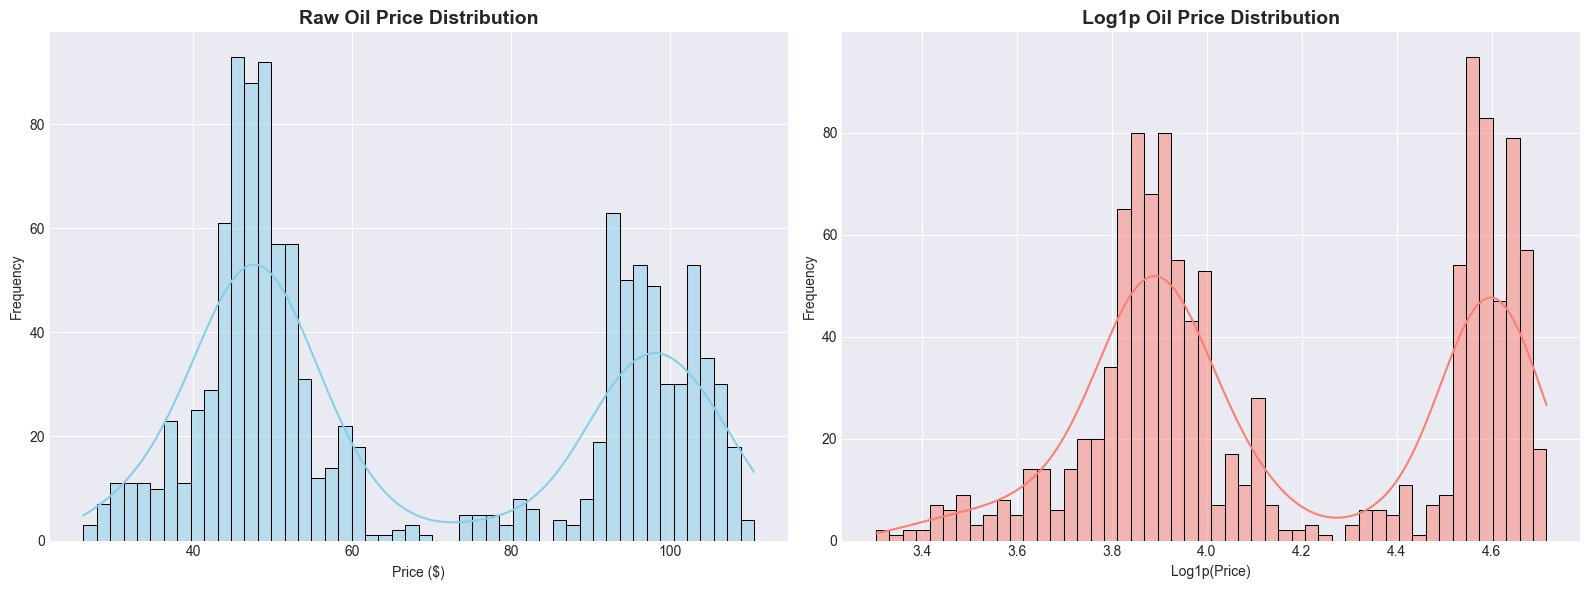

Raw Oil Price:  Skewness = 0.3216, Kurtosis = -1.6124
Log1p Oil Price: Skewness = 0.0957, Kurtosis = -1.4583


In [5]:
raw_prices = oil['dcoilwtico'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of raw prices
sns.histplot(raw_prices, bins=50, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Raw Oil Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Histogram of log-transformed prices
sns.histplot(np.log1p(raw_prices), bins=50, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Log1p Oil Price Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log1p(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Stats comparison
print(f"Raw Oil Price:  Skewness = {raw_prices.skew():.4f}, Kurtosis = {raw_prices.kurtosis():.4f}")
print(f"Log1p Oil Price: Skewness = {np.log1p(raw_prices).skew():.4f}, Kurtosis = {np.log1p(raw_prices).kurtosis():.4f}")

## 5. Long-term Trend and the 2014 Price Crash
We examine the long-term trend of oil prices from 2013 to 2017, confirming the 2014 crash and the bimodal distribution.

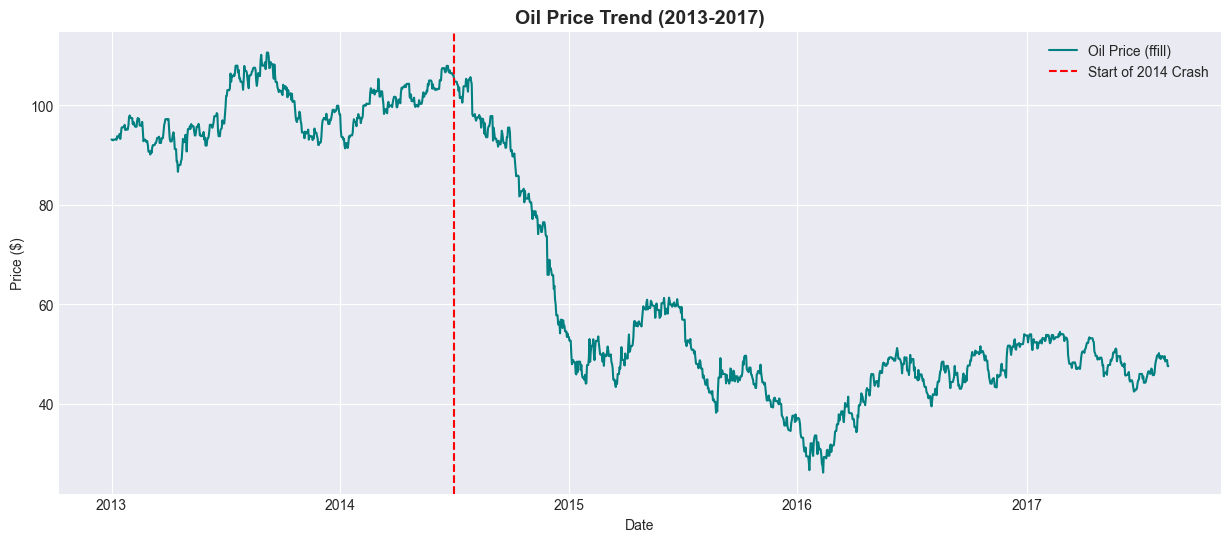

Mean Price pre-July 2014: $98.99
Mean Price post-July 2014: $52.99
Price on June 2, 2014: $103.07
Min price early 2015: $43.39 on 2015-03-17


In [6]:
plt.figure(figsize=(15, 6))
plt.plot(oil_ffill.index, oil_ffill, color='teal', label='Oil Price (ffill)')
plt.axvline(pd.Timestamp('2014-07-01'), color='red', linestyle='--', label='Start of 2014 Crash')
plt.title('Oil Price Trend (2013-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# Verify price difference pre/post crash
pre_crash = raw_prices[oil['date'][oil['dcoilwtico'].notna()] < '2014-07-01']
post_crash = raw_prices[oil['date'][oil['dcoilwtico'].notna()] >= '2014-07-01']
print(f"Mean Price pre-July 2014: ${pre_crash.mean():.2f}")
print(f"Mean Price post-July 2014: ${post_crash.mean():.2f}")

# Crash details
oil_crash_window = oil_reindexed.loc['2014-06-01':'2015-06-01', 'dcoilwtico'].dropna()
print(f"Price on June 2, 2014: ${oil_reindexed.loc['2014-06-02', 'dcoilwtico']:.2f}")
print(f"Min price early 2015: ${oil_crash_window.min():.2f} on {oil_crash_window.idxmin().date()}")

## 6. Rolling Averages (Volatility vs. Smoothness)


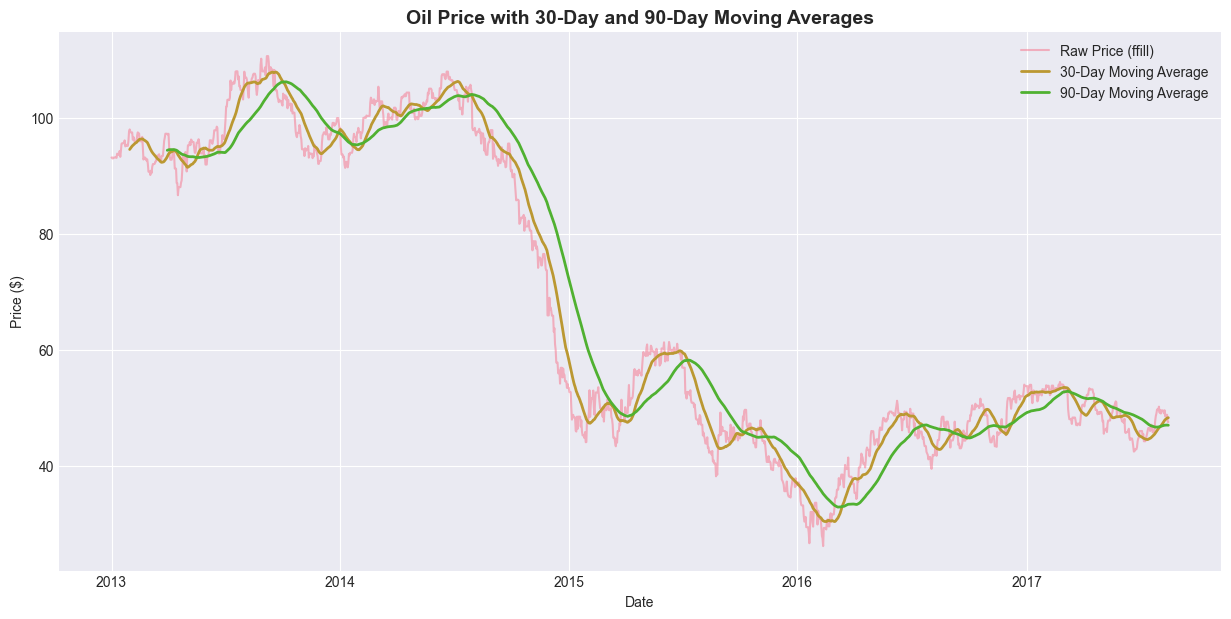

In [7]:
plt.figure(figsize=(15, 7))
plt.plot(oil_ffill.index, oil_ffill, label='Raw Price (ffill)', alpha=0.5)
plt.plot(oil_ffill.index, oil_ffill.rolling(30).mean(), label='30-Day Moving Average', linewidth=2)
plt.plot(oil_ffill.index, oil_ffill.rolling(90).mean(), label='90-Day Moving Average', linewidth=2)
plt.title('Oil Price with 30-Day and 90-Day Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# 7. Oil analysis

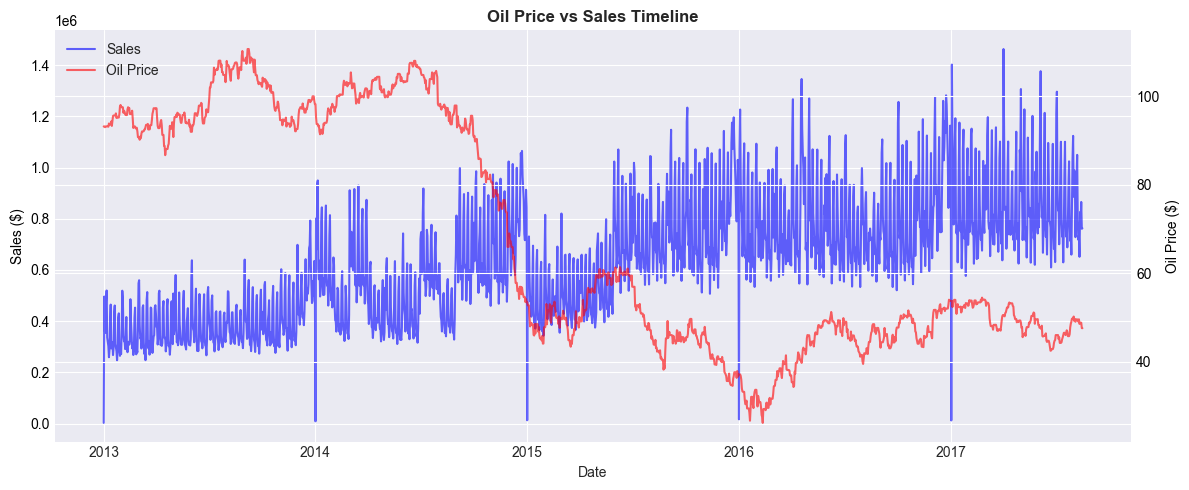

In [28]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

oil_clean = oil.copy()
oil_clean['date'] = pd.to_datetime(oil_clean['date'])

train_dates = pd.date_range(start=daily_sales['date'].min(), end=daily_sales['date'].max(), freq='D')
oil_clean = oil_clean.set_index('date').reindex(train_dates).ffill().bfill().reset_index()
oil_clean.columns = ['date', 'dcoilwtico']

df = pd.merge(daily_sales, oil_clean, on='date', how='inner')

# SỬA Ở ĐÂY: Chỉ tạo 1 plot duy nhất với ax1
fig, ax1 = plt.subplots(figsize=(12, 5))

# Vẽ Sales trên trục Y bên trái
line1 = ax1.plot(df['date'], df['sales'], color='blue', alpha=0.6, label='Sales')
ax1.set_ylabel('Sales ($)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Tạo trục Y phụ bên phải và vẽ Oil Price
ax2 = ax1.twinx()
line2 = ax2.plot(df['date'], df['dcoilwtico'], color='red', alpha=0.6, label='Oil Price')
ax2.set_ylabel('Oil Price ($)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Gộp chung Legend của cả 2 đường vào 1 hộp thoại duy nhất
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

ax1.set_title("Oil Price vs Sales Timeline", fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')

plt.tight_layout()
plt.show()
